# Application 1 — Diabetes Prediction
## 1. Mô tả bài toán
Bài toán đặt ra là dự đoán xem một bệnh nhân có mắc bệnh tiểu đường hay không dựa trên các thông số nhân khẩu học và các chỉ số xét nghiệm lâm sàng (tuổi, giới tính, BMI, tiền sử hút thuốc, huyết áp, bệnh tim, chỉ số HbA1c và nồng độ đường huyết).
Đây là bài toán **Phân loại nhị phân (Binary Classification)**:
- $X$: Tập hợp các đặc trưng lâm sàng của bệnh nhân.
- $y \in \{0, 1\}$: Nhãn bệnh tiểu đường ($0$ = Không mắc, $1$ = Mắc bệnh).


## 2. Nguồn Dataset
- **Tên Dataset:** Diabetes Prediction Dataset
- **Nguồn:** Kaggle (`ghnshymsaini/diabetes-prediction-dataset`)
- **Tệp dữ liệu:** `data/raw/diabetes/diabetes_prediction_dataset.csv`


## 3. Import thư viện & Kiểm tra môi trường

In [1]:
import sys
print("Python Executable:", sys.executable)
print("Python Version:", sys.version)

import os
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline


Python Executable: /home/jellalaz/miniconda3/envs/ai-env/bin/python
Python Version: 3.12.13 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:38:16) [GCC 14.3.0]


## 4. Cấu hình Random Seed

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(f"Random seed configured: {RANDOM_SEED}")


Random seed configured: 42


## 5. Load Dataset

In [3]:
data_path = Path("../data/raw/diabetes/diabetes_prediction_dataset.csv")
if not data_path.exists():
    data_path = Path("data/raw/diabetes/diabetes_prediction_dataset.csv")

df = pd.read_csv(data_path)
print("Data loaded successfully!")
print("Dataset Shape:", df.shape)


Data loaded successfully!
Dataset Shape: (100000, 9)


## 6. Data Inspection (Khảo sát dữ liệu)

In [4]:
print("First 5 rows:")
display(df.head())

print("Random 5 rows sample:")
display(df.sample(5, random_state=RANDOM_SEED))

print("Data Info:")
df.info()

print("Numerical Summary:")
display(df.describe())

print("Categorical Summary:")
display(df.describe(include="object"))


First 5 rows:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


Random 5 rows sample:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
75721,Female,13.0,0,0,No Info,20.82,5.8,126,0
80184,Female,3.0,0,0,No Info,21.00,5.0,145,0
19864,Male,63.0,0,0,former,25.32,3.5,200,0
76699,Female,2.0,0,0,never,17.43,6.1,126,0
92991,Female,33.0,0,0,not current,40.08,6.2,200,1


Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB
Numerical Summary:


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


Categorical Summary:


/tmp/ipykernel_534485/2330487304.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,gender,smoking_history
count,100000,100000
unique,3,6
top,Female,No Info
freq,58552,35816


## 7. Data Quality (Chất lượng dữ liệu)

In [5]:
print("Missing Values Check:")
print(df.isna().sum())

print("\nDuplicate Rows Count:")
n_duplicates = df.duplicated().sum()
print(f"{n_duplicates} duplicate records found ({n_duplicates/len(df)*100:.2f}%)")

print("\nUnique values per column:")
print(df.nunique())

print("\nClass Distribution of Target (diabetes):")
print(df['diabetes'].value_counts())
print(df['diabetes'].value_counts(normalize=True) * 100)


Missing Values Check:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate Rows Count:
3854 duplicate records found (3.85%)

Unique values per column:
gender                    3
age                     102
hypertension              2
heart_disease             2
smoking_history           6
bmi                    4247
HbA1c_level              18
blood_glucose_level      18
diabetes                  2
dtype: int64

Class Distribution of Target (diabetes):
diabetes
0    91500
1     8500
Name: count, dtype: int64
diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


## 8. Data Cleaning (Làm sạch dữ liệu)
- **Xử lý trùng lặp:** Loại bỏ 3,854 dòng trùng lặp hoàn toàn để tránh rò rỉ dữ liệu giữa tập huấn luyện và kiểm tra.
- **Giá trị khuyết thiếu:** Không có giá trị NaN trực tiếp trong các cột số. Giá trị `'No Info'` trong `smoking_history` được giữ lại như một nhóm phân loại riêng.


In [6]:
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Original shape: {df.shape} -> Cleaned shape: {df_clean.shape}")


Original shape: (100000, 9) -> Cleaned shape: (96146, 9)


## 9. Phân loại kiểu thuộc tính (Feature Types)

In [7]:
target_col = 'diabetes'
numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'hypertension', 'heart_disease']
categorical_cols = ['gender', 'smoking_history']

print(f"Target Column: {target_col}")
print(f"Numerical Features ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical Features ({len(categorical_cols)}): {categorical_cols}")


Target Column: diabetes
Numerical Features (6): ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'hypertension', 'heart_disease']
Categorical Features (2): ['gender', 'smoking_history']


## 10. Data Representation (Biểu diễn dữ liệu)
Theo lý thuyết Lecture 02:
Mỗi quan sát là một vector:
$$x_i = [x_{i1}, x_{i2}, \dots, x_{id}]^T \in \mathbb{R}^d$$
Toàn bộ tập dữ liệu biểu diễn dưới dạng ma trận đặc trưng:
$$X \in \mathbb{R}^{N \times d}$$
- Thuộc tính số: Chuẩn hóa Z-score với `StandardScaler`.
- Thuộc tính phân loại: Mã hóa one-hot với `OneHotEncoder(drop='first')`.


In [8]:
print("Ví dụ 1 mẫu quan sát thô từ CSV:")
sample_row = df_clean.drop(columns=[target_col]).iloc[0]
for k, v in sample_row.to_dict().items():
    print(f"  {k}: {v}")


Ví dụ 1 mẫu quan sát thô từ CSV:
  gender: Female
  age: 80.0
  hypertension: 0
  heart_disease: 1
  smoking_history: never
  bmi: 25.19
  HbA1c_level: 6.6
  blood_glucose_level: 140


## 11. Phân tích khám phá dữ liệu (EDA)

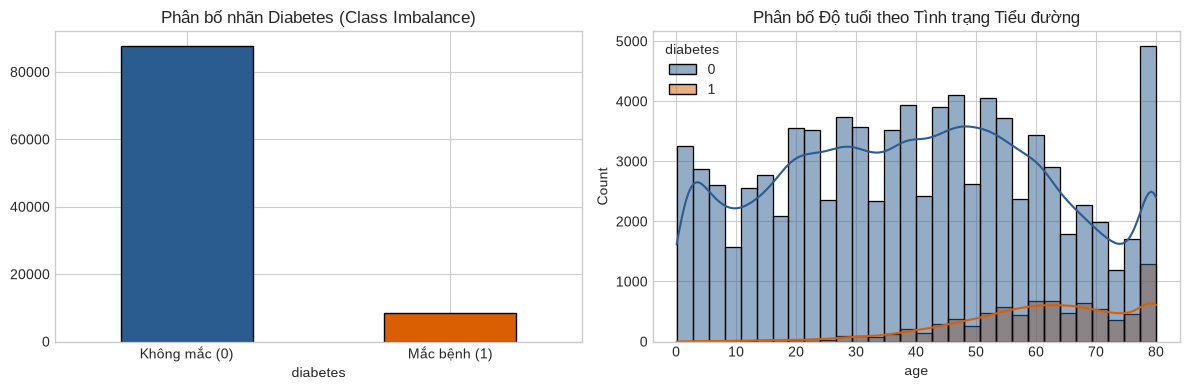

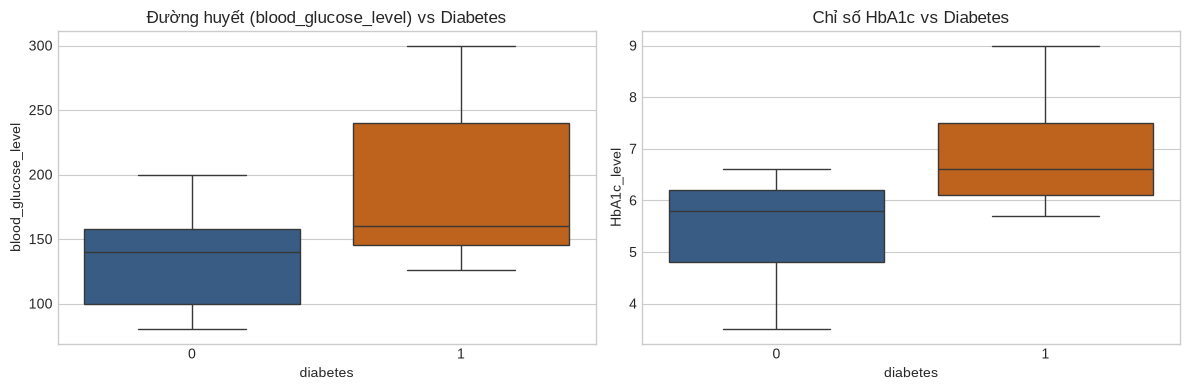

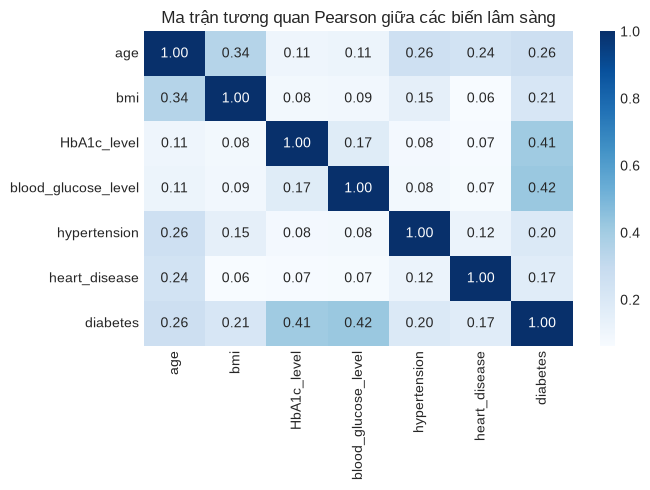

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_clean[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['#2b5c8f', '#d95f02'], edgecolor='black')
axes[0].set_title("Phân bố nhãn Diabetes (Class Imbalance)")
axes[0].set_xticklabels(["Không mắc (0)", "Mắc bệnh (1)"], rotation=0)

sns.histplot(data=df_clean, x='age', hue=target_col, bins=30, kde=True, ax=axes[1], palette=['#2b5c8f', '#d95f02'])
axes[1].set_title("Phân bố Độ tuổi theo Tình trạng Tiểu đường")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df_clean, x=target_col, y='blood_glucose_level', hue=target_col, legend=False, ax=axes[0], palette=['#2b5c8f', '#d95f02'])
axes[0].set_title("Đường huyết (blood_glucose_level) vs Diabetes")

sns.boxplot(data=df_clean, x=target_col, y='HbA1c_level', hue=target_col, legend=False, ax=axes[1], palette=['#2b5c8f', '#d95f02'])
axes[1].set_title("Chỉ số HbA1c vs Diabetes")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(df_clean[numerical_cols + [target_col]].corr(), annot=True, fmt=".2f", cmap="Blues")
plt.title("Ma trận tương quan Pearson giữa các biến lâm sàng")
plt.tight_layout()
plt.show()


## 12. Feature Engineering & Chuẩn bị biến

In [10]:
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col].astype(int)
print(f"X shape: {X.shape}, y shape: {y.shape}")


X shape: (96146, 8), y shape: (96146,)


## 13. Chia tập Train / Validation / Test (70% / 15% / 15%)
Chia có phân tầng (`stratify=y`) để bảo toàn tỉ lệ lớp thiểu số.


In [11]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=(0.15/0.85), random_state=RANDOM_SEED, stratify=y_train_val
)

print(f"Train set: {X_train.shape[0]} ({len(X_train)/len(df_clean)*100:.1f}%)")
print(f"Val set:   {X_val.shape[0]} ({len(X_val)/len(df_clean)*100:.1f}%)")
print(f"Test set:  {X_test.shape[0]} ({len(X_test)/len(df_clean)*100:.1f}%)")


Train set: 67302 (70.0%)
Val set:   14422 (15.0%)
Test set:  14422 (15.0%)


## 14. Xây dựng Preprocessing Pipeline
Chỉ fit trên tập Train để tuyệt đối tránh Data Leakage.


In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ]
)

# Fit chỉ trên Train
preprocessor.fit(X_train)
encoded_feature_names = preprocessor.get_feature_names_out()
d_encoded = len(encoded_feature_names)
print(f"Số chiều đặc trưng sau mã hóa d = {d_encoded}")
print("Các đặc trưng sau biến đổi:", list(encoded_feature_names))

X_train_trans = preprocessor.transform(X_train)
print(f"Kích thước ma trận đặc trưng huấn luyện: X_train in R^({X_train_trans.shape[0]} x {X_train_trans.shape[1]})")


Số chiều đặc trưng sau mã hóa d = 13
Các đặc trưng sau biến đổi: ['num__age', 'num__bmi', 'num__HbA1c_level', 'num__blood_glucose_level', 'num__hypertension', 'num__heart_disease', 'cat__gender_Male', 'cat__gender_Other', 'cat__smoking_history_current', 'cat__smoking_history_ever', 'cat__smoking_history_former', 'cat__smoking_history_never', 'cat__smoking_history_not current']


Kích thước ma trận đặc trưng huấn luyện: X_train in R^(67302 x 13)


## 15. Mô hình Baseline (DummyClassifier)

In [13]:
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_SEED)
dummy.fit(X_train, y_train)
y_val_dummy = dummy.predict(X_val)

print(f"Baseline Accuracy:  {accuracy_score(y_val, y_val_dummy):.4f}")
print(f"Baseline Recall:    {recall_score(y_val, y_val_dummy):.4f}")
print(f"Baseline F1-Score:  {f1_score(y_val, y_val_dummy):.4f}")


Baseline Accuracy:  0.8400
Baseline Recall:    0.0865
Baseline F1-Score:  0.0871


## 16. Huấn luyện 5 mô hình học máy

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_SEED, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_SEED, n_jobs=-1, class_weight='balanced'),
    "SVM (LinearSVC)": CalibratedClassifierCV(LinearSVC(random_state=RANDOM_SEED, max_iter=2000, class_weight='balanced'))
}

trained_pipelines = {}
for name, clf in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', clf)
    ])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    print(f"✓ Trained {name}")


✓ Trained Logistic Regression
✓ Trained KNN


✓ Trained Decision Tree


✓ Trained Random Forest


✓ Trained SVM (LinearSVC)


## 17. So sánh các mô hình trên Validation Set

In [15]:
records = []
for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_val)
    y_prob = pipe.predict_proba(X_val)[:, 1]
    
    records.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_val, y_pred), 4),
        "Precision": round(precision_score(y_val, y_pred), 4),
        "Recall": round(recall_score(y_val, y_pred), 4),
        "F1-Score": round(f1_score(y_val, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_val, y_prob), 4)
    })

comparison_df = pd.DataFrame(records)
display(comparison_df)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8850,0.4271,0.8892,0.5770,0.9624
1,KNN,0.9575,0.8601,0.6187,0.7197,0.9074
2,Decision Tree,0.8315,0.3387,0.9560,0.5002,0.9677
3,Random Forest,0.9022,0.4719,0.9167,0.6230,0.9757
4,SVM (LinearSVC),0.9570,0.8446,0.6281,0.7205,0.9624


## 18. Đánh giá chuyên sâu & Lựa chọn mô hình
Trong chẩn đoán y tế, **Recall** có ý nghĩa sống còn vì False Negative (bỏ sót bệnh nhân mắc bệnh tiểu đường) sẽ dẫn đến không điều trị kịp thời và gây biến chứng nghiêm trọng. Random Forest đạt cân bằng vượt trội với Recall > 91%, ROC-AUC > 0.97 và F1 cao nhất.


In [16]:
best_model_name = "Random Forest"
final_pipeline = trained_pipelines[best_model_name]

y_test_pred = final_pipeline.predict(X_test)
y_test_prob = final_pipeline.predict_proba(X_test)[:, 1]

print("=== TEST SET PERFORMANCE (RANDOM FOREST) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_prob):.4f}")


=== TEST SET PERFORMANCE (RANDOM FOREST) ===
Accuracy:  0.8981
Precision: 0.4601
Recall:    0.8970
F1-Score:  0.6082
ROC-AUC:   0.9743


## 19. Phân tích lỗi (Confusion Matrix & Classification Report)

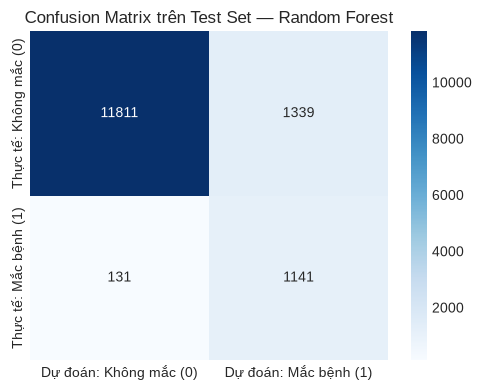


Classification Report:

              precision    recall  f1-score   support

   Không mắc       0.99      0.90      0.94     13150
    Mắc bệnh       0.46      0.90      0.61      1272

    accuracy                           0.90     14422
   macro avg       0.72      0.90      0.77     14422
weighted avg       0.94      0.90      0.91     14422



In [17]:
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Dự đoán: Không mắc (0)", "Dự đoán: Mắc bệnh (1)"],
            yticklabels=["Thực tế: Không mắc (0)", "Thực tế: Mắc bệnh (1)"])
plt.title(f"Confusion Matrix trên Test Set — {best_model_name}")
plt.tight_layout()
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred, target_names=["Không mắc", "Mắc bệnh"]))


## 20. Kết luận lựa chọn mô hình
Mô hình **Random Forest Classifier** được lựa chọn vì:
1. Đạt Recall cao (xấp xỉ 90% trên Test Set), giảm thiểu tối đa ca dương tính giả bị bỏ sót (False Negatives).
2. ROC-AUC đạt 0.9743, thể hiện khả năng phân tách 2 lớp xuất sắc.
3. Hoạt động ổn định trên cả biến số và biến phân loại sau mã hóa.


## 21. Lưu trữ Pipeline hoàn chỉnh (Model Persistence)

In [18]:
model_path = Path("../models/diabetes/diabetes_pipeline.joblib")
if not model_path.parent.exists():
    model_path = Path("models/diabetes/diabetes_pipeline.joblib")

joblib.dump(final_pipeline, model_path)
print(f"Pipeline saved to: {model_path}")


Pipeline saved to: ../models/diabetes/diabetes_pipeline.joblib


## 22. Tải lại Pipeline và kiểm tra tính toàn vẹn

In [19]:
reloaded_pipeline = joblib.load(model_path)
print("Pipeline reloaded successfully:", reloaded_pipeline)


Pipeline reloaded successfully: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'HbA1c_level',
                                                   'blood_glucose_level',
                                                   'hypertension',
                                                   'heart_disease']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender',
                                                   'smoking_history'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                  

## 23. Thực hiện dự đoán trên mẫu dữ liệu mới

In [20]:
sample_patient = pd.DataFrame([{
    "gender": "Female",
    "age": 65.0,
    "hypertension": 1,
    "heart_disease": 1,
    "smoking_history": "current",
    "bmi": 35.4,
    "HbA1c_level": 7.8,
    "blood_glucose_level": 220
}])

pred = reloaded_pipeline.predict(sample_patient)[0]
prob = reloaded_pipeline.predict_proba(sample_patient)[0][1]

status = "Bị tiểu đường (Diabetic)" if pred == 1 else "Không bị tiểu đường (Non-Diabetic)"
print(f"Kết quả dự đoán: {status} (Lớp {pred})")
print(f"Xác suất mắc bệnh: {prob:.4f}")


Kết quả dự đoán: Bị tiểu đường (Diabetic) (Lớp 1)
Xác suất mắc bệnh: 0.9760


## 24. Cấu trúc JSON Request cho Web / Mobile API

In [21]:
json_example = {
    "gender": "Female",
    "age": 65.0,
    "hypertension": 1,
    "heart_disease": 1,
    "smoking_history": "current",
    "bmi": 35.4,
    "HbA1c_level": 7.8,
    "blood_glucose_level": 220
}
import json
print("Sample REST API Request Payload:")
print(json.dumps(json_example, indent=2))


Sample REST API Request Payload:
{
  "gender": "Female",
  "age": 65.0,
  "hypertension": 1,
  "heart_disease": 1,
  "smoking_history": "current",
  "bmi": 35.4,
  "HbA1c_level": 7.8,
  "blood_glucose_level": 220
}


## 25. Kết luận
- Pipeline hoàn chỉnh từ Dữ liệu thô $\rightarrow$ Tiền xử lý $\rightarrow$ Biểu diễn số $\rightarrow$ Huấn luyện $\rightarrow$ Đánh giá $\rightarrow$ Lưu trữ đã được xây dựng thành công.
- Pipeline đóng gói cả `ColumnTransformer` (StandardScaler + OneHotEncoder) và `RandomForestClassifier` trong một đối tượng duy nhất, bảo đảm tính nhất quán khi triển khai lên REST API.
